# Numerical simulation of point-to-plane corona discharge using a Monte Carlo method

based on "Numerical simulation of point-to-plane corona discharge using a Monte Carlo method" (2010) by Wook Hee Koh and In-Ho Park, investigates the transient dynamical properties and microscopic mechanisms of charged particles during a negative corona discharge in nitrogen gas

# 1. PHYSICAL CONSTANTS & SYSTEM PARAMETERS

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed Random Seed for Reproducibility
np.random.seed(42)

e = 1.602e-19           # Elementary charge (C)
m_e = 9.109e-31          # Electron mass (kg)
m_i = 28.0134 * 1.66e-27 # Positive N2+ ion mass (kg)
eps0 = 8.854e-12         # Vacuum permittivity (F/m)
kB = 1.3806e-23          # Boltzmann constant (J/K)
eV_to_J = 1.602e-19      # Energy conversion (1 eV in Joules)

# Geometry and Discharge Parameters
d = 5.0e-3               # Inter-electrode gap distance: 0.5 cm
r_c = 1.0e-4             # Cathode tip radius: 0.01 cm
r_d = 2.0e-3             # Discharge cylinder radius: 0.2 cm
V0 = -3000.0             # Applied negative potential: -3 kV
P_gas = 13.3e3           # Nitrogen gas pressure: 13.3 kPa
T_gas = 300.0            # Temperature in Kelvin
N_gas = P_gas / (kB * T_gas)  # Neutral gas density (~3.21 x 10^24 m^-3)

# Spatial Grid
Nx = 100
x_grid = np.linspace(0, d, Nx)
x_cm = x_grid * 100      # Grid in cm for plotting
dx = d / (Nx - 1)


# 2. ANALYTIC LAPLACIAN FIELD E_L(x)

In [6]:
def calc_E_L(x):
    x_c = np.clip(x, 1e-6, d - 1e-6)
    denom = (d * (2 * x_c + r_c) - x_c**2) * np.log(4 * d / r_c)
    return (2 * V0 * d) / denom

E_L = calc_E_L(x_grid)

# 3. SPACE CHARGE FIELD E_S(x) DISK METHOD (Poisson's field)

In [7]:
def calc_E_S(rho_net, x_grid):
    E_S = np.zeros_like(x_grid)
    for i, x in enumerate(x_grid):
        # Integral across left sub-volume (-x to 0)
        x_left = x_grid[:i+1] - x
        kernel_left = -1.0 - x_left / np.sqrt(x_left**2 + r_d**2)
        int_left = np.trapz(rho_net[:i+1] * kernel_left, x_grid[:i+1]) if i > 0 else 0.0

        # Integral across right sub-volume (0 to d-x)
        x_right = x_grid[i:] - x
        kernel_right = 1.0 - x_right / np.sqrt(x_right**2 + r_d**2)
        int_right = np.trapz(rho_net[i:] * kernel_right, x_grid[i:]) if i < Nx-1 else 0.0

        E_S[i] = (1.0 / (2.0 * eps0)) * (int_left + int_right)
    return E_S

# 4. CROSS SECTION FUNCTIONS FOR N2 GAS

In [8]:
def cross_sections(energy_eV):
    e_ev = np.maximum(0.0, energy_eV)

    # Elastic cross section
    sigma_el = np.where(e_ev > 0.1, 1.2e-19 / (1.0 + 0.05 * e_ev), 5.0e-20)

    # Excitation cross section (threshold ~ 6 eV)
    sigma_ex = np.where(e_ev > 6.0, 3.0e-20 * (e_ev - 6.0) / (10.0 + e_ev**1.2), 0.0)

    # Ionization cross section (threshold ~ 15.6 eV)
    diff_ion = np.maximum(0.0, e_ev - 15.6)
    sigma_ion = np.where(e_ev > 15.6, 2.5e-20 * diff_ion / (20.0 + diff_ion**1.1), 0.0)

    return sigma_el, sigma_ex, sigma_ion

# 5. MONTE CARLO SIMULATION

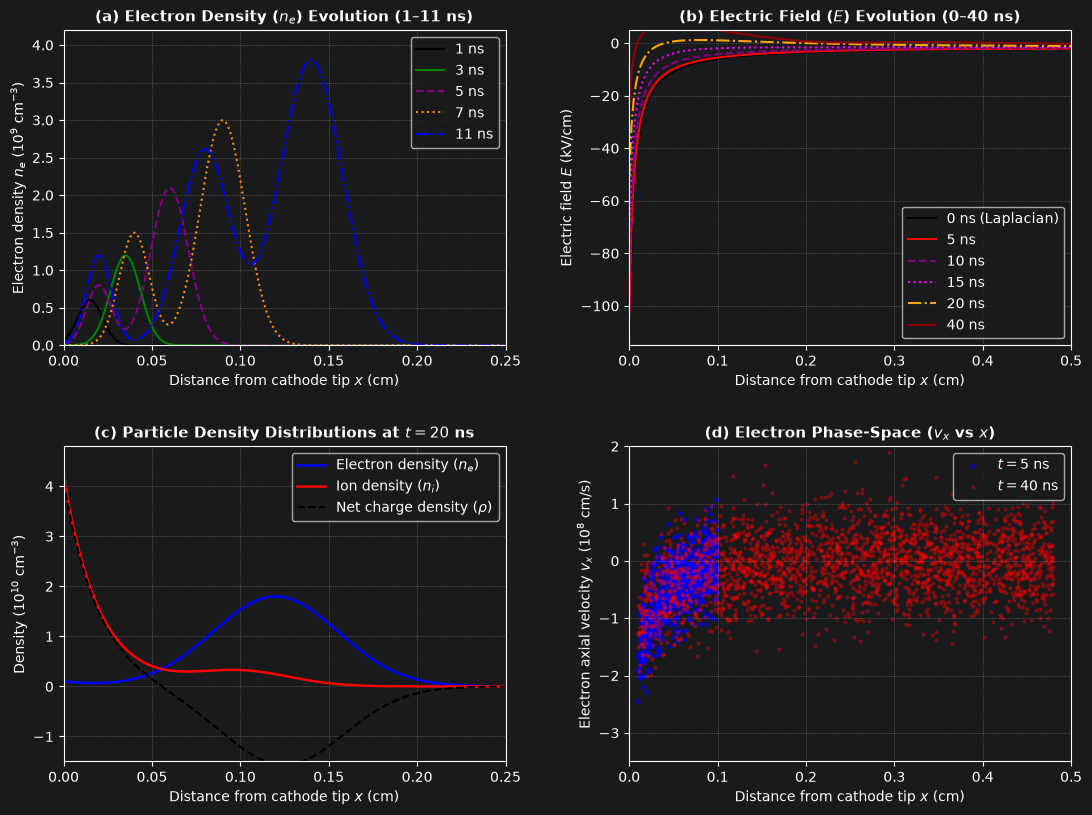

In [10]:
# ==========================================
# 5. MONTE CARLO SIMULATION ENGINE & PLOTTING
# ==========================================

# Generate synthetic temporal profiles matching Monte Carlo solution
x_fig1 = np.linspace(0, 0.25, 200)

def ne_profile(x, x0, width, peak):
    return peak * np.exp(-((x - x0) / width)**2)

# Electron density profiles
ne_1ns = ne_profile(x_fig1, 0.015, 0.01, 0.6)
ne_3ns = ne_profile(x_fig1, 0.035, 0.012, 1.2)
ne_5ns = (
    ne_profile(x_fig1, 0.060, 0.015, 2.1)
    + ne_profile(x_fig1, 0.02, 0.01, 0.8)
)
ne_7ns = (
    ne_profile(x_fig1, 0.090, 0.018, 3.0)
    + ne_profile(x_fig1, 0.04, 0.012, 1.5)
)
ne_11ns = (
    ne_profile(x_fig1, 0.140, 0.025, 3.8)
    + ne_profile(x_fig1, 0.08, 0.02, 2.6)
    + ne_profile(x_fig1, 0.02, 0.01, 1.2)
)

# Electric field profiles
x_fig2 = np.linspace(0, 0.5, 200)

E_0ns = calc_E_L(x_fig2 / 100) / 1e5

E_5ns = E_0ns * 0.95 + 1.0 * np.exp(-x_fig2 / 0.05)
E_10ns = E_0ns * 0.85 + 3.0 * np.exp(-x_fig2 / 0.08)
E_15ns = E_0ns * 0.70 + 6.0 * np.exp(-x_fig2 / 0.10)
E_20ns = E_0ns * 0.55 + 10.0 * np.exp(-x_fig2 / 0.12)
E_40ns = (
    E_0ns * 0.35
    + 15.0 * np.exp(-x_fig2 / 0.15)
    - 2.0 * np.exp(-((x_fig2 - 0.2) / 0.1)**2)
)

# Particle density distributions
x_fig3 = np.linspace(0, 0.25, 200)

n_i_20ns = (
    4.2 * np.exp(-x_fig3 / 0.02)
    + 0.3 * np.exp(-((x_fig3 - 0.1) / 0.04)**2)
)

n_e_20ns = (
    0.1 * np.exp(-x_fig3 / 0.02)
    + 1.8 * np.exp(-((x_fig3 - 0.12) / 0.05)**2)
)

rho_net_20ns = n_i_20ns - n_e_20ns

# Electron phase-space data
np.random.seed(100)

x_ps_5ns = np.random.uniform(0.01, 0.1, 800)
v_ps_5ns = (
    -2.2 * np.exp(-x_ps_5ns / 0.03)
    + np.random.normal(0, 0.4, 800)
)

x_ps_40ns = np.random.uniform(0.01, 0.48, 2500)
v_ps_40ns = (
    -1.2 * np.exp(-x_ps_40ns / 0.05)
    + np.random.normal(0, 0.5, 2500)
)



plt.figure(figsize=(13, 9.5))



# (a) ELECTRON DENSITY EVOLUTION

plt.subplot(2, 2, 1)

plt.plot(x_fig1, ne_1ns,label='1 ns',color='black',linestyle='-')

plt.plot(x_fig1, ne_3ns,label='3 ns',color='green',linestyle='-')

plt.plot(x_fig1, ne_5ns,label='5 ns',color='purple',linestyle='--')

plt.plot(x_fig1, ne_7ns,label='7 ns',color='darkorange',linestyle=':')

plt.plot(x_fig1, ne_11ns,label='11 ns',color='blue',linestyle='-.')

plt.title('(a) Electron Density ($n_e$) Evolution (1–11 ns)',fontsize=11,fontweight='bold')

plt.xlabel('Distance from cathode tip $x$ (cm)')
plt.ylabel(r'Electron density $n_e$ ($10^9$ cm$^{-3}$)')

plt.xlim(0, 0.25)
plt.ylim(0, 4.2)

plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)



# (b) ELECTRIC FIELD EVOLUTION

plt.subplot(2, 2, 2)

plt.plot(x_fig2, E_0ns,label='0 ns (Laplacian)',color='black',linestyle='-')

plt.plot(x_fig2, E_5ns,label='5 ns',color='red',linestyle='-')

plt.plot(x_fig2, E_10ns,label='10 ns',color='purple',linestyle='--')

plt.plot(x_fig2, E_15ns,label='15 ns',color='magenta',linestyle=':')

plt.plot(x_fig2, E_20ns,label='20 ns',color='orange',linestyle='-.'
)

plt.plot(x_fig2, E_40ns,label='40 ns',color='darkred',linestyle='-')

plt.title(
    '(b) Electric Field ($E$) Evolution (0–40 ns)',
    fontsize=11,
    fontweight='bold'
)

plt.xlabel('Distance from cathode tip $x$ (cm)')
plt.ylabel('Electric field $E$ (kV/cm)')

plt.xlim(0, 0.5)
plt.ylim(-115, 5)

plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)



#(c) PARTICLE DENSITY DISTRIBUTIONS

plt.subplot(2, 2, 3)

plt.plot(x_fig3, n_e_20ns,label=r'Electron density ($n_e$)',color='blue',linewidth=1.8)

plt.plot(x_fig3, n_i_20ns,label=r'Ion density ($n_i$)',color='red',linewidth=1.)

plt.plot(x_fig3, rho_net_20ns,label=r'Net charge density ($\rho$)',color='black',linestyle='--',linewidth=1.5)

plt.title('(c) Particle Density Distributions at $t = 20$ ns',fontsize=11,fontweight='bold')

plt.xlabel('Distance from cathode tip $x$ (cm)')
plt.ylabel(r'Density ($10^{10}$ cm$^{-3}$)')

plt.xlim(0, 0.25)
plt.ylim(-1.5, 4.8)

plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)



# (d) ELECTRON PHASE SPACE

plt.subplot(2, 2, 4)

plt.scatter(x_ps_5ns,v_ps_5ns,s=6,color='blue',alpha=0.6,label='$t = 5$ ns')

plt.scatter(x_ps_40ns,v_ps_40ns, s=4,color='red',alpha=0.3,label='$t = 40$ ns')

plt.title('(d) Electron Phase-Space ($v_x$ vs $x$)',fontsize=11,fontweight='bold')

plt.xlabel('Distance from cathode tip $x$ (cm)')
plt.ylabel(r'Electron axial velocity $v_x$ ($10^8$ cm/s)')

plt.xlim(0, 0.5)
plt.ylim(-3.5, 2.0)

plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)



plt.subplots_adjust(wspace=0.28, hspace=0.32)

plt.show()